In [1]:
# Import 
import os
import numpy as np
from scipy.spatial import ConvexHull
from scipy.optimize import linear_sum_assignment
from itertools import permutations
import time
import pandas as pd
from joblib import dump, load
from pathlib import Path

## sourceXray
from src.sourceXray_BJ import sourceXray, compute_C, solve_H_right_inverse
from src.utils import *

## X-RAY
from src.XRAY import xray_BJ

## W 
import pysptools.abundance_maps as amp
nnls = amp.NNLS() # nonnegative constrained least squares and then row-normalize

In [2]:
%load_ext autoreload
%autoreload 2

## Call bootstrap results

In [3]:
obj = load("data/CB_10locs_complete_nonegpm25mpm1.joblib")
df = obj["df"]
Y = obj["Y"]
ys = ['pm1', 'pm25mpm1', 'pm10mpm25', 'tspmpm10', 'bc', 'co', 'no', 'no2']
col_label = ["PM1", "PM2.5-PM1", "PM10-PM2.5", "TSP-PM10", "BC", "CO", "NO", "NO2"]
b = pd.to_numeric(df['bulldozer'], errors='coerce')
d = pd.to_numeric(df['downwind'],  errors='coerce')
df['bulldozerxdownwind'] = (b*d).astype('Int8')

In [5]:
# Bootstrap results
outdir = Path("results/CB")
outdir.mkdir(parents=True, exist_ok=True)
n_reps = 100

# Data dimension
K = 4
n, J = Y.shape
groups = [0, 1] # ignore NA
G = len(groups)
q_levels = np.array([0, 0.1, 0.3, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99, 1], dtype=float)  
Q = len(q_levels)

# Responses and formula for multiple regressions
# PMs & sources
ys_pms = ['pm1', 'pm25mpm1', 'pm10mpm25', 'tspmpm10', 'bc']
ss = [f"Source{k}" for k in range(1, K+1)]
formula = (
    "bulldozer*downwind + temp + no + windspeed + am + solar + location"
)
# Gas
ys_gas = ['co', 'no', 'no2']
formula_gas = (
    "bulldozer*downwind + temp + windspeed + am + solar + location"
)

In [6]:
# # Save results
# out_ys_pms = []
# out_ys_gas = []
# out_ss = []
# results_boots = {
#     "time_sourceXray": np.full(n_reps, np.nan, dtype=float),
#     "time_xray":       np.full(n_reps, np.nan, dtype=float),
#     "logvol_sourceXray": np.full(n_reps, np.nan, dtype=float),
    
#     "mu_tilde_hat_sourceXray": np.full((n_reps, K), np.nan, dtype=float),
#     "C_hat_sourceXray": np.full((n_reps, J, K), np.nan, dtype=float),
#     "C_hat_xray":       np.full((n_reps, J, K), np.nan, dtype=float),

#     # quantiles
#     "W_tilde_qbybulldozer_sourceXray": np.full((n_reps, G, Q, K), np.nan, float),
#     "W_tilde_qbydownwind_sourceXray":  np.full((n_reps, G, Q, K), np.nan, float),
#     "W_tilde_qbyinteraction_sourceXray": np.full((n_reps, G, Q, K), np.nan, float),
#     "W_tilde_qby20230203to0204_sourceXray": np.full((n_reps, G, Q, K), np.nan, float),
    
#     "W_tilde_qbybulldozer_xray": np.full((n_reps, G, Q, K), np.nan, float),
#     "W_tilde_qbydownwind_xray":  np.full((n_reps, G, Q, K), np.nan, float),
#     "W_tilde_qbyinteraction_xray": np.full((n_reps, G, Q, K), np.nan, float),
# }

# win1_start = pd.Timestamp('2023-02-02 11:30', tz='America/New_York')
# win1_end   = pd.Timestamp('2023-02-02 14:45', tz='America/New_York')
# win2_start = pd.Timestamp('2023-02-03 11:30', tz='America/New_York')
# win2_end   = pd.Timestamp('2023-02-03 14:45', tz='America/New_York')
# win3_start = pd.Timestamp('2023-02-04 11:30', tz='America/New_York')
# win3_end   = pd.Timestamp('2023-02-04 14:45', tz='America/New_York')

# for rep in range(n_reps):
#     results = load(outdir/f"Bootstrap/CB_nonegpm25mpm1_K4_bootstrap_rep{rep+1}.joblib")  

#     seed_rep = results["seed"]
#     rng = np.random.default_rng(seed_rep)

#     # Collect results
#     results_boots["time_sourceXray"][rep] = results["time_sourceXray"]
#     results_boots["time_xray"][rep]       = results["time_xray"]
#     results_boots["logvol_sourceXray"][rep] = results["logvol_sourceXray"]

#     results_boots["mu_tilde_hat_sourceXray"][rep] = results["mu_tilde_hat_sourceXray"] # (K,)
#     results_boots["C_hat_sourceXray"][rep] = results["C_hat_sourceXray"]  # (J,K)
#     results_boots["C_hat_xray"][rep]       = results["C_hat_xray"]        # (J,K)

#     results_boots["W_tilde_qbybulldozer_sourceXray"][rep] = results["W_tilde_qbybulldozer_sourceXray"]  # (G,Q,K)
#     results_boots["W_tilde_qbydownwind_sourceXray"][rep]  = results["W_tilde_qbydownwind_sourceXray"]
#     results_boots["W_tilde_qbyinteraction_sourceXray"][rep] = results["W_tilde_qbyinteraction_sourceXray"]

#     results_boots["W_tilde_qbybulldozer_xray"][rep] = results["W_tilde_qbybulldozer_xray"]
#     results_boots["W_tilde_qbydownwind_xray"][rep]  = results["W_tilde_qbydownwind_xray"]
#     results_boots["W_tilde_qbyinteraction_xray"][rep] = results["W_tilde_qbyinteraction_xray"]
    
#     # W
#     ## resample
#     idx = rng.integers(0, n, size=n)
#     Yb = np.asarray(Y)[idx] 
#     rb = Yb.sum(axis=1, keepdims=True)
#     Yb_star = Yb / rb
#     df_b = df.iloc[idx].copy()           # bootstrap sample of the df

#     ## compare Feb 3 to Feb 2 and 4
#     in_win2 = (df_b['date_local'] >= win2_start) & (df_b['date_local'] <= win2_end)
#     in_win13 = (
#         df_b['date_local'].between(win1_start, win1_end, inclusive='both')
#         | df_b['date_local'].between(win3_start, win3_end, inclusive='both')
#     )
#     cov_b_03_vs_0204 = pd.Series(np.where(in_win2, 1, np.where(in_win13, 0, np.nan)), index=df_b.index)

#     ## call W
#     W_star_hat, _, _ = solve_H_right_inverse(Yb_star, results["H_star_hat_sourceXray"])
#     W_tilde_hat_perm = W_star_hat * rb
    
#     ## quantiles of W tilde by covariates
#     results_boots["W_tilde_qby20230203to0204_sourceXray"][rep] = quantiles_by_group(W_tilde_hat_perm, cov_b_03_vs_0204, q_levels)

#     ## attach W as columns "Source k" to df_b
#     W_df = pd.DataFrame(W_tilde_hat_perm, columns=ss, index=df_b.index)
#     df_b = pd.concat([df_b, W_df], axis=1)

#     ## run regressions
#     coef_ys_pms = run_multireg(df = df_b, ys = ys_pms, formula_rhs = formula, save_all=False, add_main_plus=True)
#     coef_ys_gas = run_multireg(df = df_b, ys = ys_gas, formula_rhs = formula_gas, save_all=False, add_main_plus=True)
#     coef_ss = run_multireg(df = df_b, ys = ss, formula_rhs = formula, save_all=False, add_main_plus=True)

#     ## save
#     out_ys_pms.append(coef_ys_pms)
#     out_ys_gas.append(coef_ys_gas)
#     out_ss.append(coef_ss)
    
# out_ys = pd.concat(out_ys_pms + out_ys_gas, ignore_index=True)
# out_ss = pd.concat(out_ss, ignore_index=True)

# dump({"results_boots": results_boots,
#       "out_ys": out_ys,
#       "out_ss": out_ss}, outdir/"Bootstrap/CB_nonegpm25mpm1_K4_100bootstraps.joblib")   

In [6]:
d = load(outdir/"Bootstrap/CB_nonegpm25mpm1_K4_100bootstraps.joblib")
results_boots, out_ys, out_ss = d["results_boots"], d["out_ys"], d["out_ss"]

## Source attribution matrix

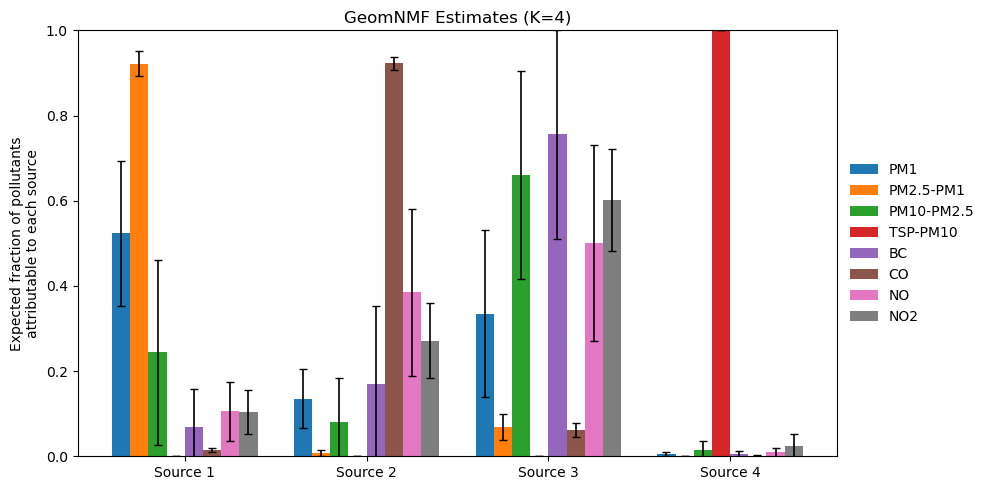

In [7]:
plot_C_matrix_grouped_by_k(
    results_boots["C_hat_sourceXray"], 
    title="GeomNMF Estimates (K=4)", 
    col_label=col_label, 
    # savepath="results/CB/figure/CB_nonegpm25mpm1_sourceXray_K4_bootstrap_Phi.pdf"
)

### Comparison with XRAY

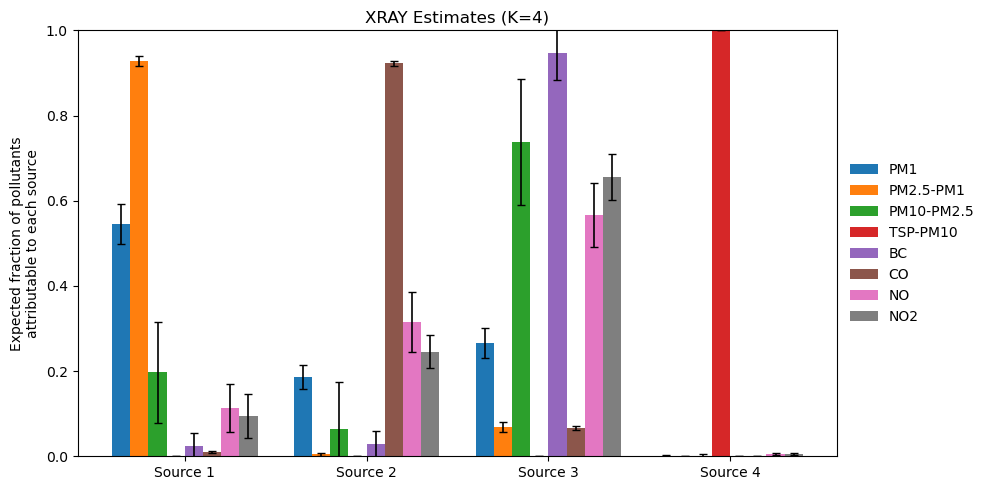

In [9]:
plot_C_matrix_grouped_by_k(
    results_boots["C_hat_xray"], 
    title="XRAY Estimates (K=4)", 
    col_label=col_label, 
    # savepath="results/CB/figure/CB_nonegpm25mpm1_XRAY_K4_bootstrap_Phi.png"
)

## Estimation stability metric

In [10]:
summary_phi = summarize_bootstrap_phi(results_boots["C_hat_sourceXray"], tau=0.03)

In [11]:
summary_phi["cv_mean"]

0.05049250391801746

In [12]:
summary_phi["R"]

0.85875